**20251028 Portfolio Review - Simple Monte Carlo Simulation**

The objective is to examine a portfolio that has invested in gold ETF for several years and have large weight in the precious metal
    
For the code base, please see my previous notebook (20250718) and the referenced page.

Code reference: https://mishraayush447.medium.com/portfolio-optimization-using-python-b8d2b64e520e

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1) The instruments in questions are as follow:

HK_2840 = SPDR Gold Trust

HK_3066 = CSOP Bitcoin Futures ETF

HK_3132 = Samsung Bloomberg Global Semiconductor ETF

BRK_B = Berkshire Hathaway Inc Class B

LVHI = Franklin Intl Low Volatility High Dividend Index

MITSY = Mitsui & Co., Ltd

NBIS = Nebius Group N.V

QQQ = Invesco QQQ Trust

UNH = UNITEDHEALTH GROUP INC

VWO = Vanguard Emerging Markets Stock Index Fund ETF

YUM = Yum! Brands

ETH = Ethereum (ETH) to US Dollar (USD)

2) Portfolio weights as of 28-10-2025

HK_2840 = 0.42

HK_3066 = 0.01

HK_3132 = 0.01

BRK_B = 0.06

LVHI = 0.04

MITSY = 0.03

NBIS = 0.10

QQQ = 0.07

UNH = 0.07

VWO = 0.06

YUM = 0.03

ETH = 0.10

3) I am interested in the following two ETFs:

URA = GLOBAL X URANIUM ETF

JEPI = JPMORGAN EQUITY PREMIUM INCO

Energy is often a topic of interest for investing community and nuclear fission based power generation continues to be one of most stable options for power generation, given its major risk under extreme scenario.   Uraninum comodity price has gained attention from institutions such as hedge funds in recent years.   As a source of power generation, this commoidty may have potential to add diversification benefit to a portfolio.  I have previously invested and exited a position in URA.

JEPI is a well known ETF that focuses on income generation.  It focuses on large cap equity in North America and has benefited from the strenght of the US stock market. One of its major risks is its expected positive correlation with US stock market.

In [2]:
np.random.seed(0)

In [3]:
#import data
HK_2840 = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/2840.csv")
HK_3066 = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/3066.csv")
HK_3132 = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/3132.csv")
BRK_B = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/BRK_B.csv")
LVHI = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/LVHI.csv")
MITSY = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/MITSY.csv")
NBIS = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/NBIS.csv")
QQQ = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/QQQ.csv")
UNH = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/UNH.csv")
VWO = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/VWO.csv")
YUM = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/YUM.csv")
ETH = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/ETH.csv")
URA = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/URA.csv")
JEPI = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/JEPI.csv")

In [4]:
#change "Date" column datatype to datatime
HK_2840['Date']= pd.to_datetime(HK_2840['Date'], format='%m-%d-%y')
HK_3066['Date']= pd.to_datetime(HK_3066['Date'], format='%m-%d-%y')
HK_3132['Date']= pd.to_datetime(HK_3132['Date'], format='%m-%d-%y')
BRK_B['Date']= pd.to_datetime(BRK_B['Date'], format='%m-%d-%y')
LVHI['Date']= pd.to_datetime(LVHI['Date'], format='%m-%d-%y')
MITSY['Date']= pd.to_datetime(MITSY['Date'], format='%m-%d-%y')
NBIS['Date']= pd.to_datetime(NBIS['Date'], format='%m-%d-%y')
QQQ['Date']= pd.to_datetime(QQQ['Date'], format='%m-%d-%y')
UNH['Date']= pd.to_datetime(UNH['Date'], format='%m-%d-%y')
VWO['Date']= pd.to_datetime(VWO['Date'], format='%m-%d-%y')
YUM['Date']= pd.to_datetime(YUM['Date'], format='%m-%d-%y')
ETH['Date']= pd.to_datetime(ETH['Date'], format='%m-%d-%y')
URA['Date']= pd.to_datetime(URA['Date'], format='%m-%d-%y')
JEPI['Date']= pd.to_datetime(JEPI['Date'], format='%m-%d-%y')

In [5]:
#set each series index to its "Date" for combining the series to dataframe
HK_2840.set_index("Date", inplace = True)
HK_3066.set_index("Date", inplace = True)
HK_3132.set_index("Date", inplace = True)
BRK_B.set_index("Date", inplace = True)
LVHI.set_index("Date", inplace = True)
MITSY.set_index("Date", inplace = True)
NBIS.set_index("Date", inplace = True)
QQQ.set_index("Date", inplace = True)
UNH.set_index("Date", inplace = True)
VWO.set_index("Date", inplace = True)
YUM.set_index("Date", inplace = True)
ETH.set_index("Date", inplace = True)
URA.set_index("Date", inplace = True)
JEPI.set_index("Date", inplace = True)

In [6]:
#selecting "Close" data column
HK_2840 = HK_2840['Close']
HK_3066 = HK_3066['Close']
HK_3132 = HK_3132['Close']
BRK_B = BRK_B['Close']
LVHI = LVHI['Close']
MITSY = MITSY['Close']
NBIS = NBIS['Close']
QQQ = QQQ['Close']
UNH = UNH['Close']
VWO = VWO['Close']
YUM = YUM['Close']
ETH = ETH['Close']
URA = URA['Close']
JEPI = JEPI['Close']

In [7]:
#rename the "Close" column to the instrument name.  These names will become the dataframe's column header
HK_2840.name = "HK_2840"
HK_3066.name = "HK_3066"
HK_3132.name = "HK_3132"
BRK_B.name = "BRK_B"
LVHI.name = "LVHI"
MITSY.name = "MITSY"
NBIS.name = "NBIS"
QQQ.name = "QQQ"
UNH.name = "UNH"
VWO.name = "VWO"
YUM.name = "YUM"
ETH.name = "ETH"
URA.name = "URA"
JEPI.name = "JEPI"

**What portfolio weights should I have if I only keep the current portfolio holdings?**

Let's use data since the beginning of 2024

In [8]:
price_data = pd.concat([HK_2840, HK_3066, HK_3132, BRK_B, LVHI, MITSY, NBIS, QQQ, UNH, VWO, YUM, ETH], axis=1)
price_data = price_data.loc[price_data.index > '2024-01-01']
price_data.head()

,HK_2840,HK_3066,HK_3132,BRK_B,LVHI,MITSY,NBIS,QQQ,UNH,VWO,YUM,ETH
Date,,,,,,,,,,,,
2024-01-02,1500.0,18.84,17.89,362.46,27.74,369.31,18.94,402.59,539.34,40.62,129.03,2360.85
2024-01-03,1494.0,18.40,17.23,366.75,27.64,371.00,18.94,398.33,542.03,40.50,129.10,2219.45
2024-01-04,1481.6,17.47,16.97,363.68,27.77,375.03,18.94,396.28,545.42,40.43,128.69,2277.50
2024-01-05,1479.6,17.85,16.92,365.59,27.86,377.36,18.94,396.75,537.38,40.49,128.34,2241.35
2024-01-08,1470.6,17.83,17.06,368.18,28.03,382.80,18.94,404.95,536.52,40.56,128.64,2337.90


In [9]:
#calculate daily return
price_return = price_data.pct_change(fill_method=None).dropna()
price_return.head()

,HK_2840,HK_3066,HK_3132,BRK_B,LVHI,MITSY,NBIS,QQQ,UNH,VWO,YUM,ETH
Date,,,,,,,,,,,,
2024-01-03,-0.004000,-0.023355,-0.036892,0.011836,-0.003605,0.004576,0.0,-0.010581,0.004988,-0.002954,0.000543,-0.059894
2024-01-04,-0.008300,-0.050543,-0.015090,-0.008371,0.004703,0.010863,0.0,-0.005146,0.006254,-0.001728,-0.003176,0.026155
2024-01-05,-0.001350,0.021752,-0.002946,0.005252,0.003241,0.006213,0.0,0.001186,-0.014741,0.001484,-0.002720,-0.015873
2024-01-08,-0.006083,-0.001120,0.008274,0.007084,0.006102,0.014416,0.0,0.020668,-0.001600,0.001729,0.002338,0.043077
2024-01-09,0.002720,0.070667,0.024619,-0.003477,-0.007849,-0.021552,0.0,0.001976,0.003448,-0.011588,-0.003265,-0.037020


In [10]:
#calculate annualized mean
price_return.mean()*252

HK_2840    0.337674
HK_3066    0.715703
HK_3132    0.601193
BRK_B      0.304673
LVHI       0.178445
MITSY      0.188438
NBIS       1.345610
QQQ        0.328213
UNH       -0.049486
VWO        0.217093
YUM        0.226419
ETH        0.728949
dtype: float64

In [11]:
#calculate annualized standard deivation
price_return.std()*252

HK_2840     2.513271
HK_3066     7.959436
HK_3132     5.562886
BRK_B       2.509768
LVHI        1.687487
MITSY       4.707043
NBIS       14.361255
QQQ         3.350917
UNH         6.436409
VWO         2.444910
YUM         3.035377
ETH        10.948397
dtype: float64

In [12]:
#calculate annualized covariance matrix.  This is required to calculate portfolio volatility/sd
price_return.cov()*252

,HK_2840,HK_3066,HK_3132,BRK_B,LVHI,MITSY,NBIS,QQQ,UNH,VWO,YUM,ETH
HK_2840,0.025066,0.003566,0.002104,0.000230,0.000440,0.005566,0.004599,-0.000107,0.006523,0.002077,0.001560,0.002572
HK_3066,0.003566,0.251399,0.070561,0.007436,0.001947,0.003060,0.030064,0.010890,-0.007718,0.005446,-0.007668,0.069615
HK_3132,0.002104,0.070561,0.122800,-0.001219,-0.002322,0.002758,0.027044,0.009538,-0.012779,0.007252,-0.001783,0.017426
BRK_B,0.000230,0.007436,-0.001219,0.024996,0.007850,0.013902,-0.006530,0.010128,0.009541,0.005121,0.006836,0.021353
LVHI,0.000440,0.001947,-0.002322,0.007850,0.011300,0.018545,0.011655,0.011721,0.004289,0.009214,0.005377,0.017591
MITSY,0.005566,0.003060,0.002758,0.013902,0.018545,0.087922,0.043458,0.028968,0.005035,0.020662,0.008784,0.050385
NBIS,0.004599,0.030064,0.027044,-0.006530,0.011655,0.043458,0.818435,0.075316,0.018241,0.038594,-0.017294,0.127947
QQQ,-0.000107,0.010890,0.009538,0.010128,0.011721,0.028968,0.075316,0.044558,0.001227,0.020557,0.007288,0.068877
UNH,0.006523,-0.007718,-0.012779,0.009541,0.004289,0.005035,0.018241,0.001227,0.164394,0.003763,0.009306,0.001481
VWO,0.002077,0.005446,0.007252,0.005121,0.009214,0.020662,0.038594,0.020557,0.003763,0.023721,0.007264,0.038289


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

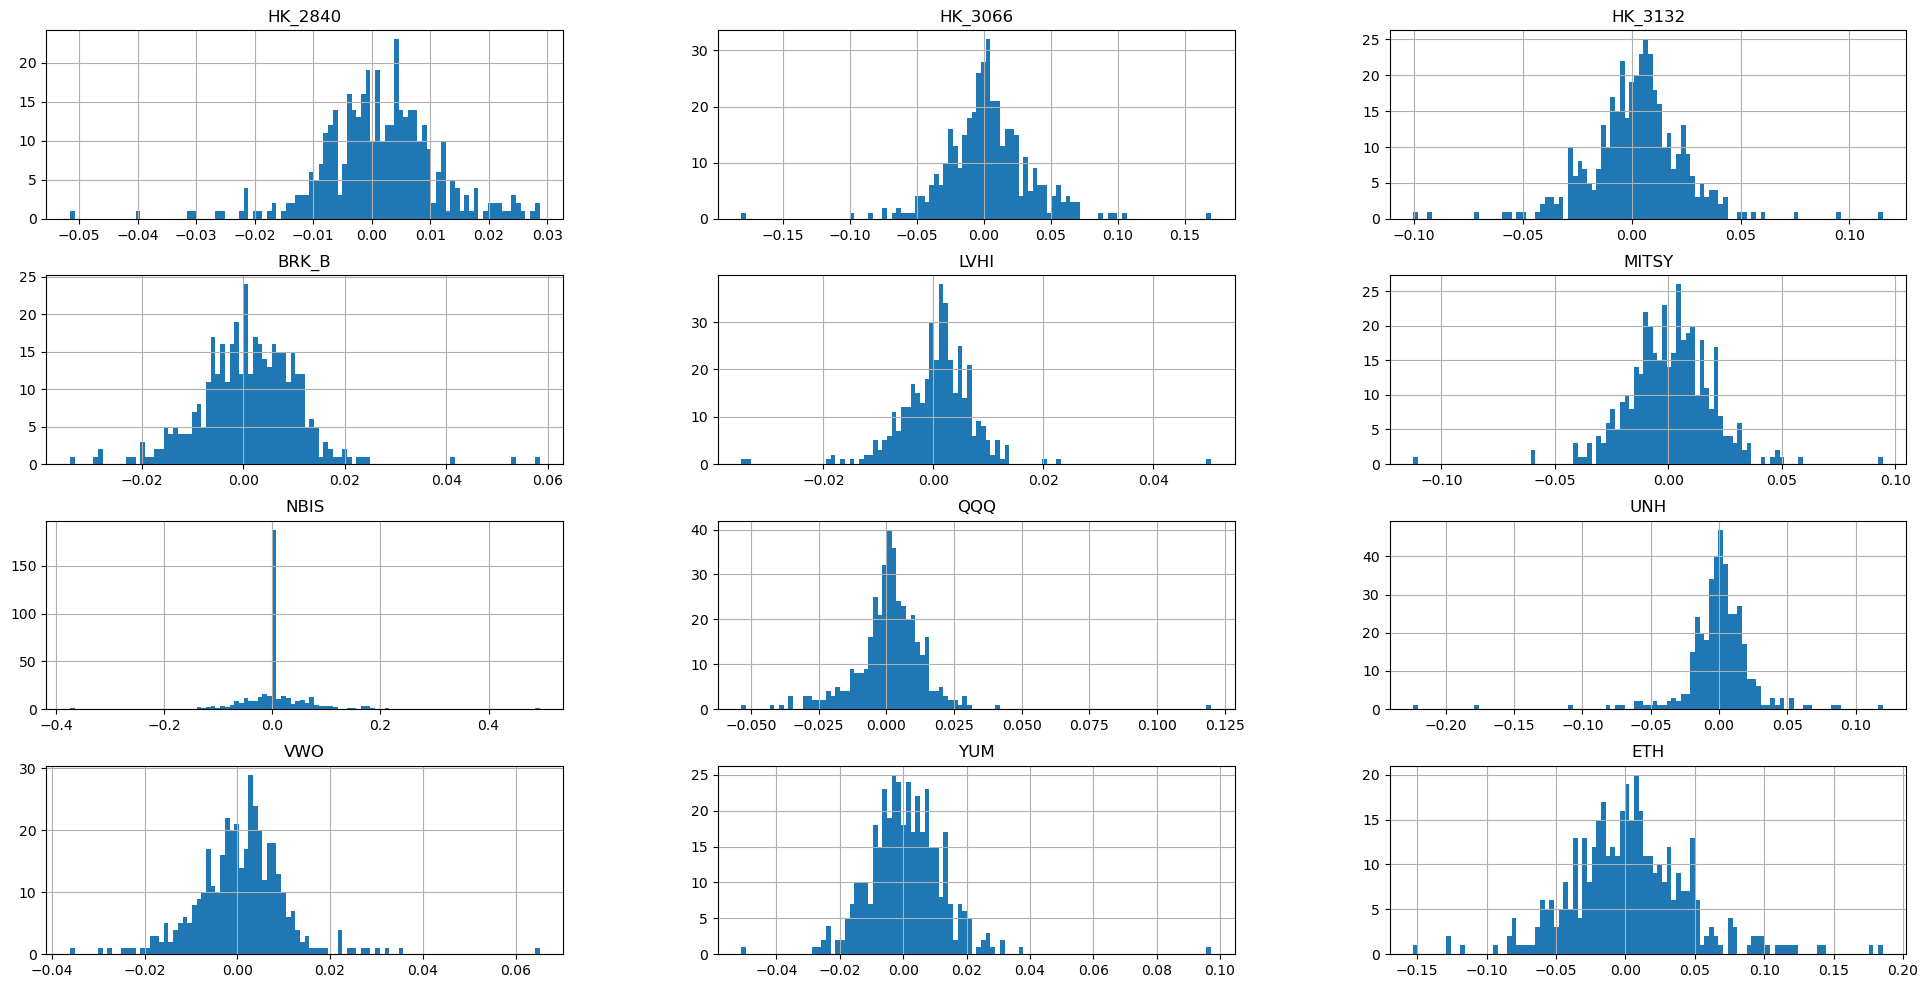

In [13]:
price_return.hist(figsize = (24,12), bins=100)
plt.tight_layout

Monte Carlo Simulation

The number of simulated portfolio is set to 100,000.   Risk free rate is assumed to be close to US Treasury 10-Y Bond yield.

The objective of the optimization is to maximize the Sharpe ratio of a portfolio.  The Sharpe Ratio is defined as:

(Portfolio Return - Risk Free Rate)/(Portfolio volatility)

In this exercise, we will annualize return and volatility (standard deviation).

In [14]:
rate_free = 0.03972 #2025-10-28 UST 10Y yield is around 3.972% (Asia close time)
current_weights = np.array([0.42, 0.01, 0.01, 0.06, 0.04,
       0.03, 0.10, 0.07, 0.07, 0.06,
       0.03, 0.10])
current_returns = np.sum(price_return.mean()*252*current_weights)
current_std = np.sqrt(np.dot(current_weights.T, np.dot(price_return.cov()*252,current_weights)))
current_sharpe = (current_returns-rate_free)/current_std
current_sharpe

2.3445102181080917

In [15]:
n = 100000
count_asset = 12
rate_free = 0.03972 #2025-10-28 UST 10Y yield is around 3.972% (Asia close time)
simulated_weights = np.zeros((n, count_asset))
simulated_returns = np.zeros(n)
simulated_std = np.zeros(n)
simulated_sharpe = np.zeros(n)

for i in range(n):
    weights = np.array(np.random.random(count_asset))
    weights = weights/np.sum(weights)
    simulated_weights[i,:] = weights
    simulated_returns[i] = np.sum(price_return.mean()*252*weights)
    simulated_std[i] = np.sqrt(np.dot(weights.T, np.dot(price_return.cov()*252,weights)))
    simulated_sharpe[i] = (simulated_returns[i]-rate_free)/simulated_std[i]

In [16]:
simulated_sharpe.max()

3.0439482962089874

In [17]:
simulated_sharpe.argmax()

88781

In [18]:
simulated_weights[simulated_sharpe.argmax(), :]

array([0.17911437, 0.07695329, 0.12410286, 0.17774391, 0.14633796,
       0.01680384, 0.02982368, 0.01429392, 0.02601729, 0.03415261,
       0.15868429, 0.01597199])

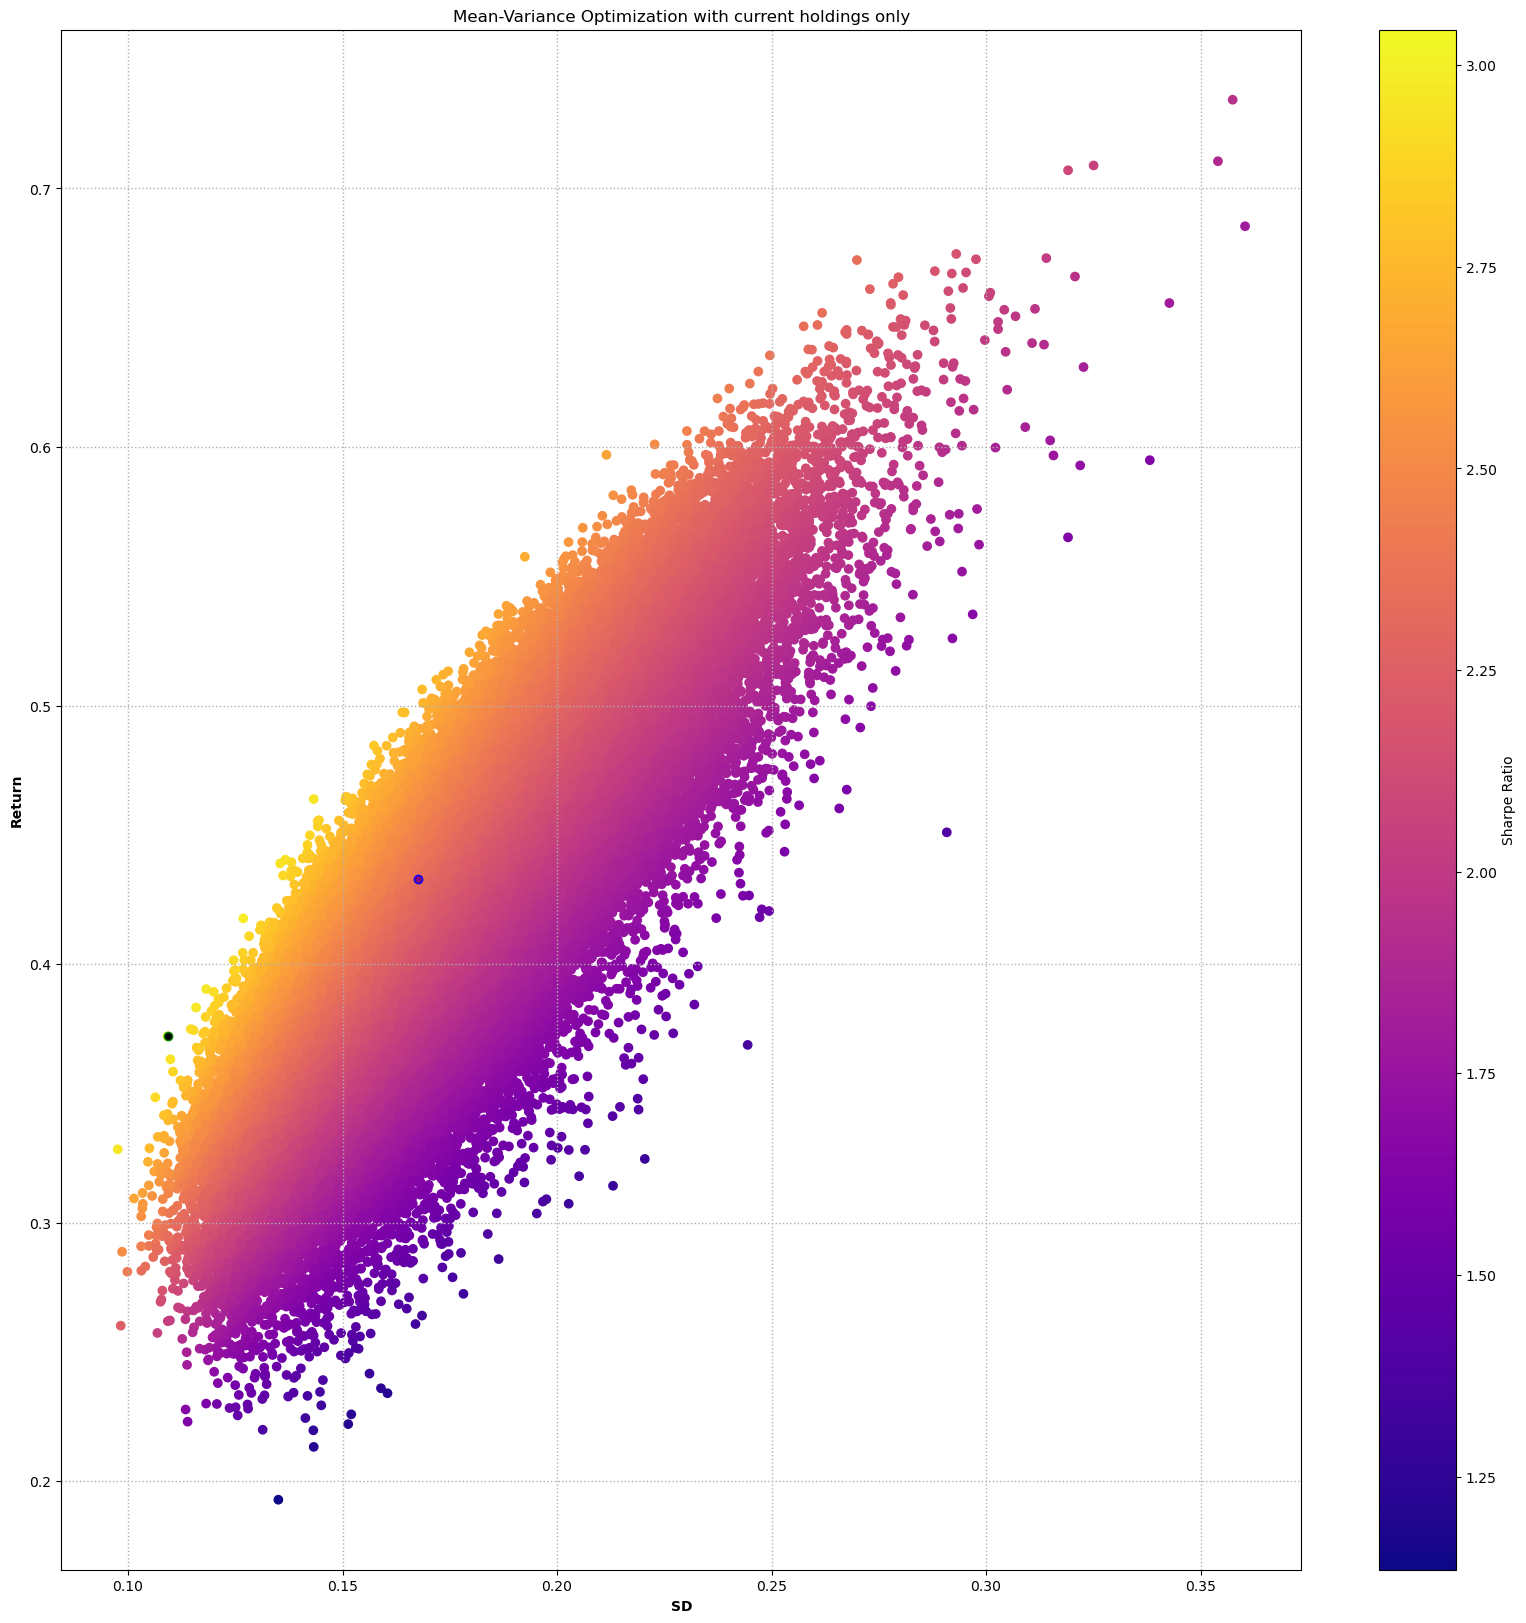

In [19]:
plt.figure(figsize = (20,20))
plt.title("Mean-Variance Optimization with current holdings only")
plt.scatter(simulated_std, simulated_returns, c=simulated_sharpe, cmap="plasma")
plt.colorbar(label = "Sharpe Ratio")
plt.xlabel("SD", fontweight = 'bold')
plt.ylabel("Return", fontweight = 'bold')

plt.scatter(simulated_std[simulated_sharpe.argmax()], simulated_returns[simulated_sharpe.argmax()], 
            c = 'black', edgecolors='green')
plt.scatter(current_std, current_returns, 
            c = 'purple', edgecolors='blue')
plt.grid(True, ls=':', lw=1)

The optimized portfolio is recommended to have the following weights:

HK_2840 SPDR Gold Trust = 0.17911437

HK_3066 CSOP Bitcoin Futures ETF = 0.07695329

HK_3132 Samsung Bloomberg Global Semiconductor ETF = 0.12410286

BRK_B Berkshire Hathaway Inc Class B = 0.17774391

LVHI Franklin Intl Low Volatility High Dividend Index = 0.14633796

MITSY Mitsui & Co., Ltd = 0.01680384

NBIS Nebius Group N.V = 0.02982368

QQQ Invesco QQQ Trust = 0.01429392

UNITEDHEALTH GROUP INC = 0.02601729

VWO Vanguard Emerging Markets Stock Index Fund ETF = 0.03415261

YUM Yum! Brands = 0.15868429

ETH Ethereum (ETH) to US Dollar (USD) = 0.01597199

**What portfolio weights should I have if I add two more instruments?**

All other parameters remain the same

In [20]:
price_data_add = pd.concat([HK_2840, HK_3066, HK_3132, BRK_B, LVHI, MITSY, NBIS, QQQ, UNH, VWO, YUM, ETH, URA, JEPI], axis=1)
price_data_add = price_data_add.loc[price_data_add.index > '2024-01-01']
price_data_add.head()

,HK_2840,HK_3066,HK_3132,BRK_B,LVHI,MITSY,NBIS,QQQ,UNH,VWO,YUM,ETH,URA,JEPI
Date,,,,,,,,,,,,,,
2024-01-02,1500.0,18.84,17.89,362.46,27.74,369.31,18.94,402.59,539.34,40.62,129.03,2360.85,27.13,55.12
2024-01-03,1494.0,18.40,17.23,366.75,27.64,371.00,18.94,398.33,542.03,40.50,129.10,2219.45,26.83,54.81
2024-01-04,1481.6,17.47,16.97,363.68,27.77,375.03,18.94,396.28,545.42,40.43,128.69,2277.50,27.20,54.79
2024-01-05,1479.6,17.85,16.92,365.59,27.86,377.36,18.94,396.75,537.38,40.49,128.34,2241.35,26.96,54.75
2024-01-08,1470.6,17.83,17.06,368.18,28.03,382.80,18.94,404.95,536.52,40.56,128.64,2337.90,27.36,55.12


In [21]:
#calculate daily return
price_return_add = price_data_add.pct_change(fill_method=None).dropna()
price_return_add.head()

,HK_2840,HK_3066,HK_3132,BRK_B,LVHI,MITSY,NBIS,QQQ,UNH,VWO,YUM,ETH,URA,JEPI
Date,,,,,,,,,,,,,,
2024-01-03,-0.004000,-0.023355,-0.036892,0.011836,-0.003605,0.004576,0.0,-0.010581,0.004988,-0.002954,0.000543,-0.059894,-0.011058,-0.005624
2024-01-04,-0.008300,-0.050543,-0.015090,-0.008371,0.004703,0.010863,0.0,-0.005146,0.006254,-0.001728,-0.003176,0.026155,0.013791,-0.000365
2024-01-05,-0.001350,0.021752,-0.002946,0.005252,0.003241,0.006213,0.0,0.001186,-0.014741,0.001484,-0.002720,-0.015873,-0.008824,-0.000730
2024-01-08,-0.006083,-0.001120,0.008274,0.007084,0.006102,0.014416,0.0,0.020668,-0.001600,0.001729,0.002338,0.043077,0.014837,0.006758
2024-01-09,0.002720,0.070667,0.024619,-0.003477,-0.007849,-0.021552,0.0,0.001976,0.003448,-0.011588,-0.003265,-0.037020,0.040570,-0.000726


In [22]:
#calculate annualized mean
price_return_add.mean()*252

HK_2840    0.337674
HK_3066    0.715703
HK_3132    0.601193
BRK_B      0.304673
LVHI       0.178445
MITSY      0.188438
NBIS       1.345610
QQQ        0.328213
UNH       -0.049486
VWO        0.217093
YUM        0.226419
ETH        0.728949
URA        0.391582
JEPI       0.106639
dtype: float64

In [23]:
#calculate annualized standard deivation
price_return_add.std()*252

HK_2840     2.513271
HK_3066     7.959436
HK_3132     5.562886
BRK_B       2.509768
LVHI        1.687487
MITSY       4.707043
NBIS       14.361255
QQQ         3.350917
UNH         6.436409
VWO         2.444910
YUM         3.035377
ETH        10.948397
URA         6.365040
JEPI        1.687742
dtype: float64

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

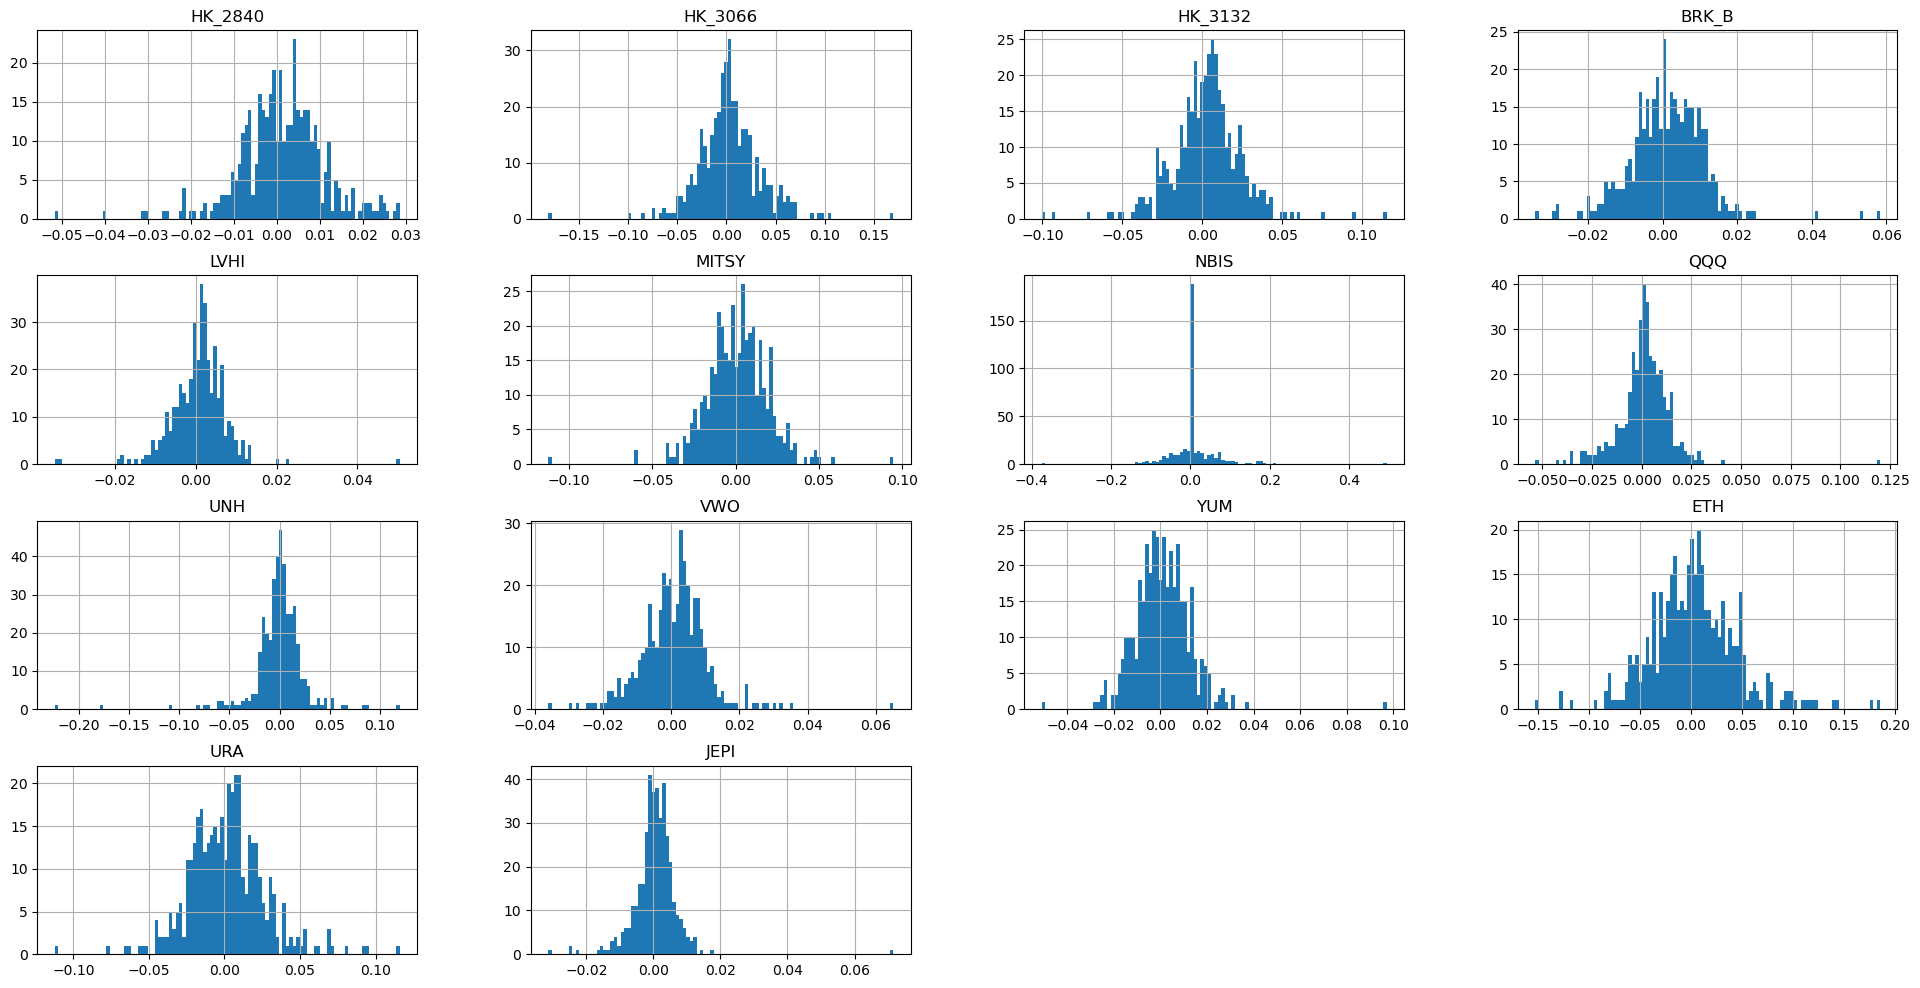

In [24]:
price_return_add.hist(figsize = (24,12), bins=100)
plt.tight_layout

In [25]:
rate_free = 0.03972 #2025-10-28 UST 10Y yield is around 3.972% (Asia close time)
current_weights_add = np.array([0.42, 0.01, 0.01, 0.06, 0.04,
       0.03, 0.10, 0.07, 0.07, 0.06,
       0.03, 0.10, 0.00, 0.00])
current_returns_add = np.sum(price_return_add.mean()*252*current_weights_add)
current_std_add = np.sqrt(np.dot(current_weights_add.T, np.dot(price_return_add.cov()*252,current_weights_add)))
current_sharpe_add = (current_returns_add-rate_free)/current_std_add
current_sharpe_add

2.3445102181080917

In [26]:
n = 100000
count_asset_add = 14
rate_free = 0.03972 #2025-10-28 UST 10Y yield is around 3.972% (Asia close time)
simulated_weights_add = np.zeros((n, count_asset_add))
simulated_returns_add = np.zeros(n)
simulated_std_add = np.zeros(n)
simulated_sharpe_add = np.zeros(n)

for i in range(n):
    weights_add = np.array(np.random.random(count_asset_add))
    weights_add = weights_add/np.sum(weights_add)
    simulated_weights_add[i,:] = weights_add
    simulated_returns_add[i] = np.sum(price_return_add.mean()*252*weights_add)
    simulated_std_add[i] = np.sqrt(np.dot(weights_add.T, np.dot(price_return_add.cov()*252,weights_add)))
    simulated_sharpe_add[i] = (simulated_returns_add[i]-rate_free)/simulated_std_add[i]

In [27]:
simulated_sharpe_add.max()

2.8815807963869404

In [28]:
simulated_sharpe_add.argmax()

7674

In [29]:
simulated_weights_add[simulated_sharpe_add.argmax(), :]

array([0.14876358, 0.09101811, 0.17650407, 0.12071002, 0.03694403,
       0.00232791, 0.04335712, 0.02921053, 0.00290445, 0.05712259,
       0.19120781, 0.04453314, 0.03460635, 0.02079028])

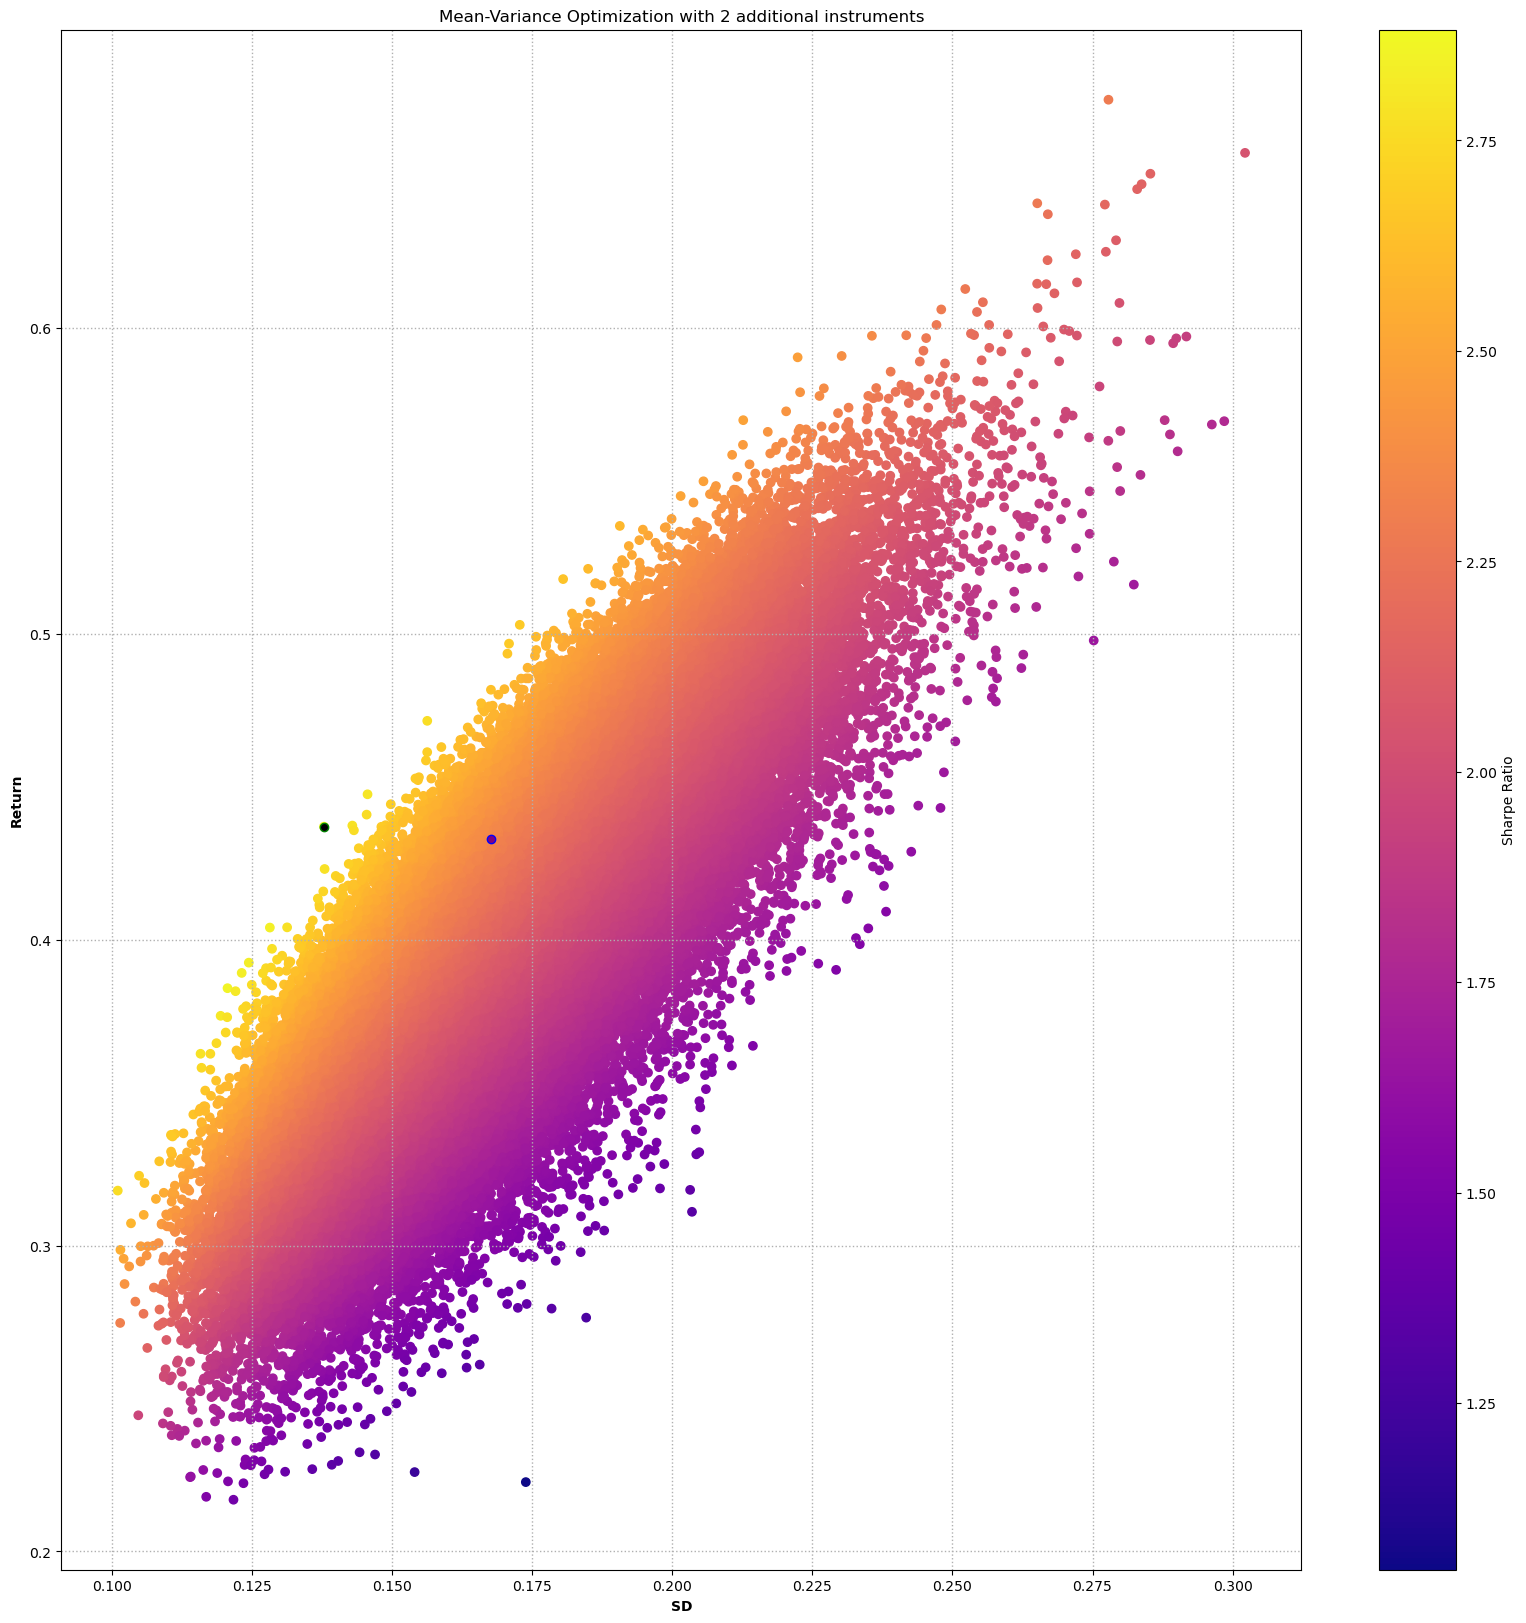

In [30]:
plt.figure(figsize = (20,20))
plt.title("Mean-Variance Optimization with 2 additional instruments")
plt.scatter(simulated_std_add, simulated_returns_add, c=simulated_sharpe_add, cmap="plasma")
plt.colorbar(label = "Sharpe Ratio")
plt.xlabel("SD", fontweight = 'bold')
plt.ylabel("Return", fontweight = 'bold')

plt.scatter(simulated_std_add[simulated_sharpe_add.argmax()], simulated_returns_add[simulated_sharpe_add.argmax()], 
            c = 'black', edgecolors='green')
plt.scatter(current_std_add, current_returns_add, 
            c = 'purple', edgecolors='blue')
plt.grid(True, ls=':', lw=1)


The optimized portfolio is recommended to have the following weights:

HK_2840 SPDR Gold Trust = 0.14876358

HK_3066 CSOP Bitcoin Futures ETF = 0.09101811

HK_3132 Samsung Bloomberg Global Semiconductor ETF =  0.17650407

BRK_B Berkshire Hathaway Inc Class B = 0.12071002

LVHI Franklin Intl Low Volatility High Dividend Index = 0.03694403

MITSY Mitsui & Co., Ltd = 0.00232791

NBIS Nebius Group N.V = 0.04335712

QQQ Invesco QQQ Trust = 0.02921053

UNITEDHEALTH GROUP INC = 0.00290445

VWO Vanguard Emerging Markets Stock Index Fund ETF = 0.05712259

YUM Yum! Brands = 0.19120781

ETH Ethereum (ETH) to US Dollar (USD) = 0.04453314

URA GLOBAL X URANIUM ETF = 0.03460635

JEPI JPMORGAN EQUITY PREMIUM INCO = 0.02079028